In [7]:
#importing necessary libs
import numpy as np
import matplotlib.pyplot as plt

In [8]:
#generation of data
def gen_data():
    np.random.seed(42)
    n = 100
    class0 = np.random.randn(n,2)*1.5 + np.array([2,2])
    class1 = np.random.randn(n,2)*1.5 + np.array([4,4])

    X = np.vstack((class0, class1))
    Y = np.array([0]*n + [1]*n)

    noise_ratio = 0.1
    num_noisy = int(noise_ratio * len(Y))
    noise_idx = np.random.choice(len(Y), num_noisy, replace=False)
    Y[noise_idx] = 1 - Y[noise_idx]  
    return X, Y

In [9]:
#distance function
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

#KNN prediction
def knn_pred(X_train, Y_train, X_test, k=3):

    dist = []
    for i in range(len(X_train)):
        d = euclidean_distance(X_test, X_train[i])
        dist.append((d, Y_train[i]))

    dist.sort(key=lambda x: x[0])
    k_nearest = dist[:k]
    labels = [label for _, label in k_nearest]
    preds = max(set(labels), key=labels.count)
    return preds


In [10]:
# accuracy
def compute_accuracy(X, y, k=3):
    correct = 0

    for i in range(len(X)):
        x_test = X[i]
        y_true = y[i]

        X_train = np.delete(X, i, axis=0)
        y_train = np.delete(y, i)

        y_pred = knn_pred(X_train, y_train, x_test, k)

        if y_pred == y_true:
            correct += 1

    return correct / len(X)

In [11]:
# visualization 
def plot_data(X, y):
    plt.scatter(X[:,0], X[:,1], c=y)
    plt.title("Dataset")
    plt.show()


def plot_decision_boundary(X, y, k=3):
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 100),
        np.linspace(y_min, y_max, 100)
    )

    Z = np.zeros(xx.shape)

    for i in range(xx.shape[0]):
        for j in range(xx.shape[1]):
            point = np.array([xx[i, j], yy[i, j]])
            Z[i, j] = knn_pred(X, y, point, k)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y)
    plt.title(f"KNN Decision Boundary (K={k})")
    plt.show()


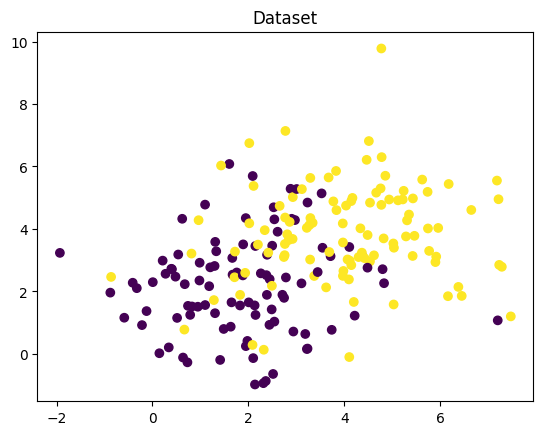

K=1, Accuracy=0.67
K=3, Accuracy=0.72
K=5, Accuracy=0.73
K=7, Accuracy=0.76
K=15, Accuracy=0.80
K=35, Accuracy=0.79
K=50, Accuracy=0.81


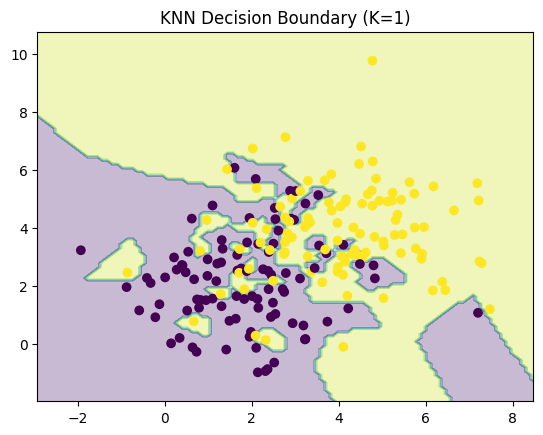

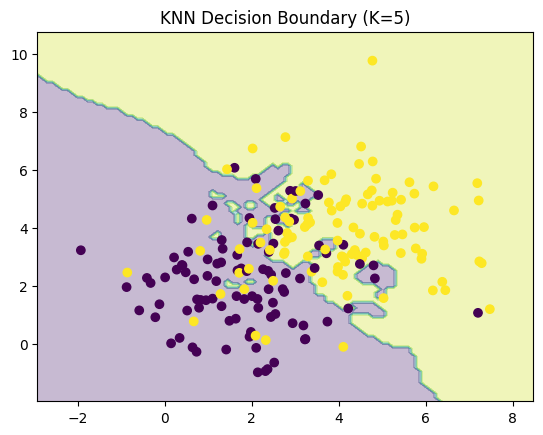

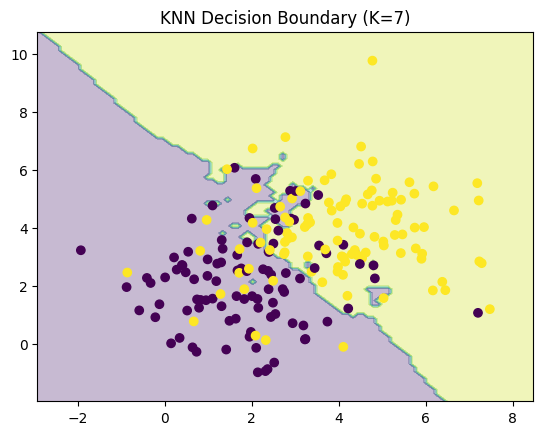

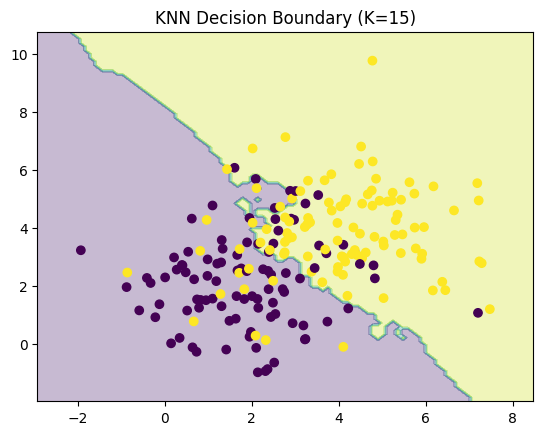

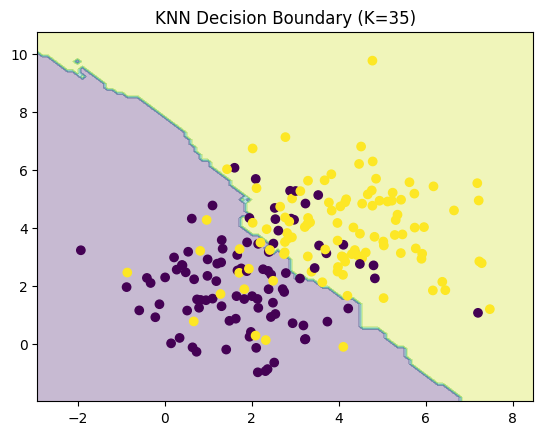

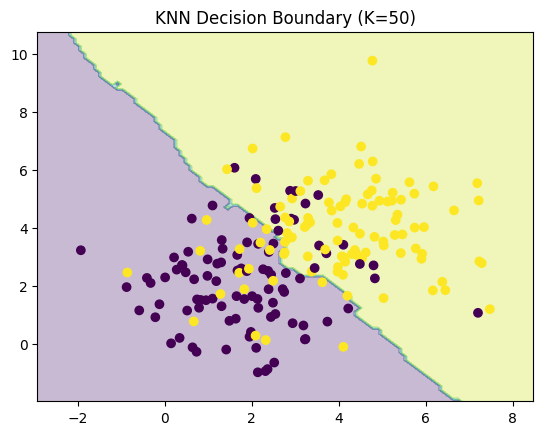

In [14]:
#main func
if __name__ == "__main__":
    
    X, y = gen_data()

    plot_data(X, y)

    for k in [1, 3, 5, 7, 15, 35, 50]:
        acc = compute_accuracy(X, y, k)
        print(f"K={k}, Accuracy={acc:.2f}")

    plot_decision_boundary(X, y, k=1)
    plot_decision_boundary(X, y, k=5)
    plot_decision_boundary(X, y, k=7)
    plot_decision_boundary(X, y, k=15)
    plot_decision_boundary(X, y, k=35)
    plot_decision_boundary(X, y, k=50)

### Observations:--
 - with K = 1 we get extreme over fitting  with 67 accuracy
 - with k = 15 we get an almost straight line and a very high accuracy
 - with k = 35, there is more straight lineness but the accuracy decreased 
 - with k = 50, increases the accuracy again and line loses its curves more 